In *LangGraph*, there are two primary approaches to building workflows and agentic applications these are:

*   **Graph API:** This is considered the standard and most intuitive method for constructing agentic workflows. You explicitly define **nodes** (the steps or processing units) and **edges** (the connections defining the flow of execution). You then compile these components into a structured graph object that manages the state and execution logic. The instructor notes that if you are building complex, stateful workflows, the *Graph API* offers the most control and is typically the recommended path.

*   **Functional API:** This approach allows you to define the graph logic using a more functional programming style. Instead of manually constructing the graph through nodes and edges via the *Graph API*, you utilize functional abstractions to manage the workflow. While it is a powerful alternative, the course suggests that it requires more specialized expertise to implement compared to the *Graph API*.

*LangGraph* is described as an essential framework for building agentic AI applications. Its architecture is built around three fundamental components:

* **Nodes:** These represent the core processing units or "steps" within the workflow. For example, in a chatbot application, a node could be a function that calls an *LLM* or performs a specific tool execution.
* **Edges:** These define the control flow or the "path" between nodes. They determine the sequence in which the nodes are executed, allowing for complex decision-making, such as routing to specific tools or finalizing an output.
* **State:** This is a crucial component that maintains the context throughout the graph execution. A **State Graph** uses this to ensure that all nodes can access and modify shared data variables, such as chat history, generated content, or intermediate calculation results, keeping the entire workflow synchronized.

### Build A Basic Chatbot With Langgraph(GRAPH API)

In [1]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm=ChatGroq(model="llama-3.1-8b-instant")

In [5]:
llm=init_chat_model("groq:llama-3.1-8b-instant")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001E081B64250>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001E081B64790>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [6]:
## Node Functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [7]:
graph_builder=StateGraph(State)

## Adding node
graph_builder.add_node("llmchatbot",chatbot)
## Adding Edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

## compile the graph
graph=graph_builder.compile()

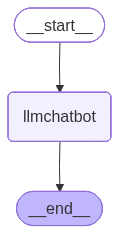

In [8]:
## Visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [9]:
response=graph.invoke({"messages":"Hi"})

In [10]:
response["messages"][-1].content

'How can I assist you today?'

In [11]:
for event in graph.stream({"messages":"Hi How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

I'm doing well, thank you for asking. I'm a large language model, so I don't have emotions or feelings like humans do, but I'm always happy to chat with you and assist with any questions or topics you'd like to discuss. How about you? How's your day going so far?


## Chat bot with tools

In [12]:
from langchain_tavily import TavilySearch

tool=TavilySearch(max_results=2)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the AI workflow as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this sense, the n

In [13]:
## Custom function
def multiply(a:int,b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [14]:
tools=[tool,multiply]

In [15]:
llm_with_tool=llm.bind_tools(tools)
llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001E081B64250>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001E081B64790>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engin

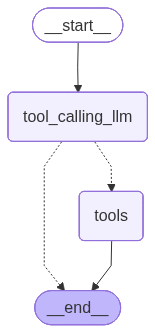

In [16]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))



In [17]:
response=graph.invoke({"messages":"What is the recent ai news"})
response['messages'][-1].content

'{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": ["https://news.admind.ai/wp-content/uploads/2024/01/AI-NEWS-ADMIND.AI-7.jpg", "https://www.vtnetzwelt.com/wp-content/uploads/2026/01/Top-AI-Technology-Updates-January-2027.webp", "https://assets.seobotai.com/cdn-cgi/image/quality=75,w=1536,h=1024/aiapps.com/68dd8f21e3dd4bddfa63c8d2-1759472051163.jpg", "https://i.ytimg.com/vi/h5u4bgErk0g/maxresdefault.jpg", "https://miro.medium.com/v2/resize:fit:1358/1*CKRZs5O0_JEDzh8kJ8WTCA.jpeg"], "results": [{"url": "https://apnews.com/article/openai-new-york-times-ai-copyright-lawsuit-7ce19c7a25aad60d4c94556d36e96cc9", "title": "News outlets urge a judge to sanction OpenAI in a high-stakes AI copyright fight - AP News", "score": 0.7135319, "published_date": "Thu, 09 Jul 2026 14:39:31 GMT", "content": "The New York Times sued OpenAI and Microsoft in late 2023, about a year after ChatGPT’s debut sparked a commercial AI boom and began changing the way people search for 

In [18]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (b3aqf5fqf)
 Call ID: b3aqf5fqf
  Args:
    include_images: True
    query: recent ai news
    search_depth: advanced
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": ["https://news.admind.ai/wp-content/uploads/2024/01/AI-NEWS-ADMIND.AI-7.jpg", "https://www.vtnetzwelt.com/wp-content/uploads/2026/01/Top-AI-Technology-Updates-January-2027.webp", "https://assets.seobotai.com/cdn-cgi/image/quality=75,w=1536,h=1024/aiapps.com/68dd8f21e3dd4bddfa63c8d2-1759472051163.jpg", "https://i.ytimg.com/vi/h5u4bgErk0g/maxresdefault.jpg", "https://miro.medium.com/v2/resize:fit:1358/1*CKRZs5O0_JEDzh8kJ8WTCA.jpeg"], "result

In [19]:
response=graph.invoke({"messages":"What is 5 multiplied by 2"})
for m in response['messages']:
    m.pretty_print()


================================ Human Message =================================

What is 5 multiplied by 2
================================== Ai Message ==================================
Tool Calls:
  multiply (cfsamjc85)
 Call ID: cfsamjc85
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: multiply

10


In [20]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (54fwgwsgs)
 Call ID: 54fwgwsgs
  Args:
    query: recent ai news
    time_range: day
    topic: news
  multiply (x7zpdzf0g)
 Call ID: x7zpdzf0g
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.washingtonpost.com/business/2026/07/09/openai-new-york-times-ai-copyright-lawsuit/1f749fa0-7ba4-11f1-b194-f872dd4ec5aa_story.html", "title": "News outlets urge a judge to sanction OpenAI in a high-stakes AI copyright fight - The Washington Post", "score": 0.64746445, "published_date": "Thu, 09 Jul 2026 14:45:58 GMT", "content": "# News outlets urge a judge to 

### ReAct Agent Architecture

The **ReAct (Reason + Act)** architecture is a powerful framework that allows AI agents to perform complex tasks by combining reasoning with external tool usage. Instead of simply predicting an output, the model cycles through a process of reasoning about a task and then acting upon it using tools.

### Core Components:
* **Reason (Reasoning):** The LLM acts as the "brain." It evaluates the input and breaks down complex tasks into smaller, manageable steps.
* **Act:** When the model realizes it cannot answer a part of a query with its internal knowledge, it makes a call to an external tool.
* **Observe:** After the tool executes, the output is fed back into the LLM as "context" (or observation). The model then observes this new information and decides on the next step—either making another tool call or summarizing the final answer.

### Why it’s revolutionary:
This iterative loop allows the agent to handle multi-step requests. For example, if asked to "Get the latest AI news and then multiply 5 by 10," the ReAct agent will perform the search, process the news, then switch to the calculator tool for the math, and finally synthesize the results into one cohesive response.

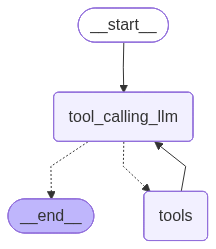

In [21]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [22]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (97ty4dhes)
 Call ID: 97ty4dhes
  Args:
    query: recent AI news
    time_range: day
    topic: news
  multiply (2pxywghyf)
 Call ID: 2pxywghyf
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.washingtonpost.com/business/2026/07/09/openai-new-york-times-ai-copyright-lawsuit/1f749fa0-7ba4-11f1-b194-f872dd4ec5aa_story.html", "title": "News outlets urge a judge to sanction OpenAI in a high-stakes AI copyright fight - The Washington Post", "score": 0.64746445, "published_date": "Thu, 09 Jul 2026 14:45:58 GMT", "content": "# News outlets urge a judge to 

## Adding Memory In Agentic Graph

In **LangGraph**, adding memory enables your agent to **remember past interactions**, allowing it to maintain context across multiple sessions. Without it, an agent treats every query as a new, isolated event.

### How it works:
* **Checkpointing**: The system uses a **checkpointer** (specifically an in-memory saver) to store the conversation history and state at each node during execution.
* **Persistence**: By passing a `checkpointer` object when compiling the graph (`graph.compile(checkpointer=memory)`), you ensure the agent can recall previous turns.
* **Thread IDs**: To manage specific user sessions, you provide a `thread_id` within the configuration. This allows the graph to retrieve the correct history for a specific conversation session.

### Why it is essential:
* **Contextual Awareness**: It allows the chatbot to answer follow-up questions like "What was my name?" by referencing stored history.
* **Session Management**: It enables the system to handle multiple, independent conversations simultaneously without data from one session leaking into another.

By integrating this memory, your agent evolves from a stateless calculator into a **conversational assistant** that understands the flow of a multi-turn dialogue.

In [23]:
response=graph.invoke({"messages":"Hello my name is Aditya"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello my name is Aditya
================================== Ai Message ==================================

Hello Aditya, it's nice to meet you. Is there anything I can help you with or would you like to chat?


In [24]:
response=graph.invoke({"messages":"What is my name"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is my name
================================== Ai Message ==================================

I don't have any information about your name. I'm a large language model, I don't have personal knowledge or access to your personal data. If you want to share your name with me, I can try to remember it for our conversation.


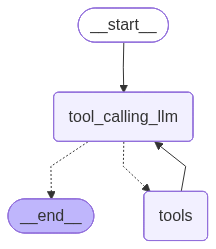

In [25]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [26]:
config={"configurable":{"thread_id":"1"}}

response=graph.invoke({"messages":"Hi my name is Aditya"},config=config)

response



{'messages': [HumanMessage(content='Hi my name is Aditya', additional_kwargs={}, response_metadata={}, id='8822378f-6a80-4b60-a2c7-e8d949d0d6ca'),
  AIMessage(content='Nice to meet you Aditya. Is there something I can help you with?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 1752, 'total_tokens': 1770, 'completion_time': 0.038060769, 'completion_tokens_details': None, 'prompt_time': 0.160496663, 'prompt_tokens_details': None, 'queue_time': 0.049163414, 'total_time': 0.198557432}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f47d9-4d87-7b53-bb1e-6afea63d4c40-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1752, 'output_tokens': 18, 'total_tokens': 1770})]}

In [27]:
response['messages'][-1].content

'Nice to meet you Aditya. Is there something I can help you with?'

In [28]:
response=graph.invoke({"messages":"Hey what is my name"},config=config)

print(response['messages'][-1].content)

Your name is Aditya.


In [29]:
response=graph.invoke({"messages":"Hey do you remember my name"},config=config)

print(response['messages'][-1].content)

Your name is Aditya.


### Streaming

In [30]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()

In [31]:
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

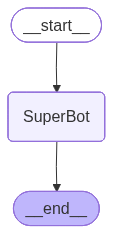

In [32]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile(checkpointer=memory)


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [33]:
## Invocation

config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({'messages':"Hi,My name is Krish And I like cricket"},config)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='1eb14380-6c3d-4336-950b-0b8e0feb22a5'),
  AIMessage(content="Nice to meet you, Krish. Cricket is a fantastic sport, and I'm happy to chat with you about it. Do you have a favorite team or player? Are you a fan of the Indian cricket team, or do you have a different favorite?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 45, 'total_tokens': 97, 'completion_time': 0.075286864, 'completion_tokens_details': None, 'prompt_time': 0.002756329, 'prompt_tokens_details': None, 'queue_time': 0.05344475, 'total_time': 0.078043193}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f47db-6f7d-71e3-9f07-c37dcc810a98-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_token

### Streaming 
Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- **values** : This streams the full state of the graph after each node is called.
- **updates** : This streams updates to the state of the graph after each node is called.

In **LangGraph**, streaming refers to the ability to receive output from your agentic workflow in real-time, rather than waiting for the entire process to finish before seeing the result. This significantly enhances user experience, especially in long-running or complex agentic chains.

### Key Streaming Concepts:
* **`graph.stream()`**: Instead of using `graph.invoke()`, which waits for the final response, `stream()` allows you to iterate over chunks or events as they are generated.
* **Values vs. Updates**: When streaming, you can choose the `mode` of output:
    * **`values`**: Returns the full state of the graph at each step. This keeps the entire conversation history appended to the output as it evolves.
    * **`updates`**: Returns only the specific updates (the new messages or changes) made by the node that is currently executing. This is more efficient if you only need the latest AI output.
* **`astream_events`**: For more granular control and debugging, you can use `astream_events` to monitor every event happening within the graph, including tool calls and internal node transitions.

In [34]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Hello Krish, nice to meet you. I'm glad to hear that you like cricket. Cricket is a fantastic sport with a huge following worldwide. Which team or player is your favorite in international cricket?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 41, 'prompt_tokens': 45, 'total_tokens': 86, 'completion_time': 0.07664386, 'completion_tokens_details': None, 'prompt_time': 0.003253929, 'prompt_tokens_details': None, 'queue_time': 0.05481073, 'total_time': 0.079897789}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f47db-e667-7ca3-b9f0-7c9dc8e43639-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'output_tokens': 41, 'total_tokens': 86})]}}


In [35]:
for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='c2da9193-1c7f-4286-8ff2-93fc22f64847'), AIMessage(content="Hello Krish, nice to meet you. I'm glad to hear that you like cricket. Cricket is a fantastic sport with a huge following worldwide. Which team or player is your favorite in international cricket?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 41, 'prompt_tokens': 45, 'total_tokens': 86, 'completion_time': 0.07664386, 'completion_tokens_details': None, 'prompt_time': 0.003253929, 'prompt_tokens_details': None, 'queue_time': 0.05481073, 'total_time': 0.079897789}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f47db-e667-7ca3-b9f0-7c9dc8e43639-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'output_toke

In [36]:
# Create a thread
config = {"configurable": {"thread_id": "4"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Nice to meet you, Krish. Cricket is a fantastic sport, isn't it? Which team do you support? Are you a fan of Indian cricket, or do you follow other teams like the Australians, English, or South Africans?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 45, 'total_tokens': 93, 'completion_time': 0.068295556, 'completion_tokens_details': None, 'prompt_time': 0.003009333, 'prompt_tokens_details': None, 'queue_time': 0.054867746, 'total_time': 0.071304889}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f47dc-59a1-7030-89ae-3be28e0e812e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'output_tokens': 48, 'total_tokens': 93})]}}


In [37]:
for chunk in graph_builder.stream({'messages':"I also like football"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='1b97bca3-ac8d-47b8-a389-9cfdd68184d4'), AIMessage(content="Nice to meet you, Krish. Cricket is a fantastic sport, isn't it? Which team do you support? Are you a fan of Indian cricket, or do you follow other teams like the Australians, English, or South Africans?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 45, 'total_tokens': 93, 'completion_time': 0.068295556, 'completion_tokens_details': None, 'prompt_time': 0.003009333, 'prompt_tokens_details': None, 'queue_time': 0.054867746, 'total_time': 0.071304889}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f47dc-59a1-7030-89ae-3be28e0e812e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'ou

In [38]:
config = {"configurable": {"thread_id": "5"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is Krish and I like to play cricket"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Krish and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019f47dc-b8ec-7a61-bb15-711aafb71279', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is Krish and I like to play cricket', additional_kwargs={}, response_metadata={}, id='b21870d9-2d01-4b7c-834c-88a169fbf5e0')]}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '019f47dc-b8f3-79f3-8c30-6ae3e130f24f', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:2faf8938-8f10-9c3f-0802-5595723618be'}, 'parent_ids': ['019f47dc-b8ec-7a61-bb15-711aafb71279']}
{'event': 'on_chain_stream', 'run_id': '019f47dc-b8f3-79f3-8c30